## **SETUP**

In [2]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from catboost import CatBoostClassifier
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv("playground-series-s6e6/train.csv")

baris, kolom = df.shape
print(f"Baris: {baris}, Kolom: {kolom}")
df.head()

Baris: 577347, Kolom: 12


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## **EDA**

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [18]:
X = df.drop("id", axis=1)
y = df["class"]

In [20]:
def line_chart_to_target(X, y):
    n = len(X.columns)
    fig, axes = plt.subplots(n, 1, figsize=(6, 4*n))

    for i, col in enumerate(X.columns):
        axes[i].plot(y, X[col])
        axes[i].set_title(f'{col} vs Target')

    plt.tight_layout()
    plt.show()

line_chart_to_target(X,y)

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 600x4400 with 11 Axes>

## **Data Cleaning**

In [21]:
missing_data = df.isnull().sum()
missing_data = missing_data.sort_values(ascending= False)
missing_data

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

Data tidak ada yang hilang

In [22]:
y = df["class"]
X = df.drop(["class"], axis=1)
cat_col = ['spectral_type', 'galaxy_population']

## **Mutual Information**

In [23]:
# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()
diskrit = X.dtypes == int

In [24]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, diskrit)
mi_scores

id                   0.879847
redshift             0.514988
spectral_type        0.299984
z                    0.211516
galaxy_population    0.192690
u                    0.178884
g                    0.174579
i                    0.158244
alpha                0.139913
delta                0.130151
r                    0.097924
Name: MI Scores, dtype: float64

In [25]:
model = CatBoostClassifier(
    iterations=1000, 
    learning_rate= 0.05,
    depth = 8,
    loss_function= 'MultiClass',
    eval_metric= 'TotalF1',
    cat_features= cat_col,
    random_seed= 42)

## **Feature Engineering**

In [26]:
#seberapa  dekat ke infrared
df["u-g"] = df["u"] - df["g"]
df["g-r"] = df["g"] - df["r"]
df["r-i"] = df["r"] - df["i"]
df["i-z"] = df["i"] - df["z"]

fe = ["u-g", 'g-r','r-i', 'i-z']

### **MI Score after Feature Engineering**

In [27]:
y = df["class"]
X = df.drop(["class", "alpha", "delta"], axis=1)

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()
diskrit = X.dtypes == int

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, diskrit)
mi_scores

id                   0.879847
redshift             0.514989
g-r                  0.321158
spectral_type        0.299984
r-i                  0.218325
z                    0.211511
galaxy_population    0.192690
u                    0.178886
g                    0.174588
u-g                  0.171351
i                    0.158247
r                    0.097929
i-z                  0.074758
Name: MI Scores, dtype: float64

### **Clustering**

In [28]:
def  Clustering(df, col, n, name, is_scaling=True):
    X_cluster = df[col]
    
    if not is_scaling:
        X_scaled = StandardScaler().fit_transform(X_cluster)
    else:
        X_scaled = X_cluster

    kmeans = KMeans(n_clusters= n, random_state=42)
    cluster = kmeans.fit_predict(X_scaled)
    X_cluster = pd.DataFrame(cluster, columns=[name])
    X_cluster = X_cluster.astype("category")
    
    return X_cluster

In [29]:
filter_col = ['u-g', 'g-r', 'r-i', 'i-z']

cluster = Clustering(df, filter_col, 3, 'group_colour', is_scaling= True)

cluster.head()


,group_colour
0,2
1,1
2,0
3,2
4,2


### **PCA**

In [50]:
def pca_gen(df, col, is_scaling= True):
    pca = PCA()
    pca_col = df[col]

    if is_scaling:
        X_scaled = StandardScaler().fit_transform(pca_col)
    else:
        X_scaled = pca_col

    X_pca = pca.fit_transform(X_scaled)

    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)

    loadings = pd.DataFrame(
    pca.components_.T,  # transpose the matrix of loadings
    columns=component_names,  # so the columns are the principal components
    index=pca_col.columns,  # and the rows are the original features
)
    return X_pca, loadings, plot_variance(pca)

def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

,PC1,PC2,PC3,PC4
u-g,0.411861,-0.557286,0.689703,-0.210030
g-r,0.631002,0.040705,-0.110409,0.766805
r-i,0.527112,-0.211075,-0.642153,-0.515015
i-z,0.392887,0.802012,0.315848,-0.320402


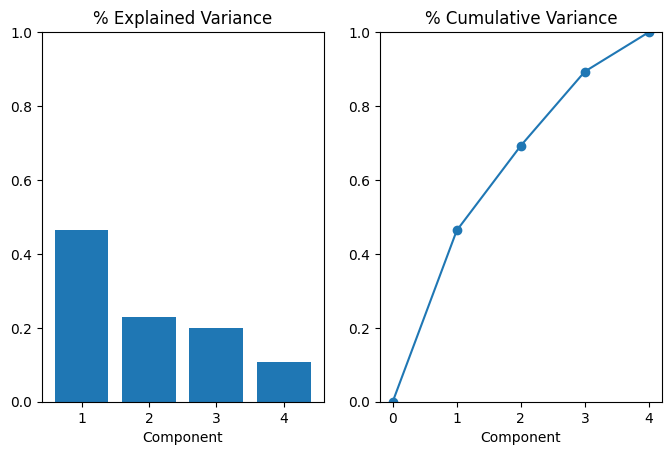

In [52]:
X_pca, loadings, variance_plot = pca_gen(df, filter_col)

loadings

AttributeError: 'PCA' object has no attribute 'n_components_'

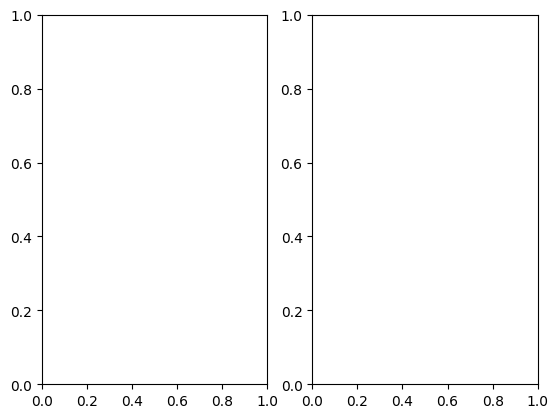

In [48]:
pca= PCA()
plot_variance(pca)